In [1]:
import kwant
import kwant.continuum
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import tinyarray
from scipy import constants

En este caso se tiene que el halmintoniano al cual se quiere simular es equivalente a: 

 $H(Ψ)=D₁∇⁴Ψ+D₂∇²Ψ+ ϵΨ= iħ ∂Ψ/∂t$

Que al usar kwant, lo que buscamos es usar el modelo tight-binding real del grafeno, es decir escribirlo bajo el halmintonino estandar   

$$H = -t \sum_{\langle i,j\rangle} c_i^\dagger c_j$$

Para lo cual es necesario discretizar el operador diferencial sobre la red. Dado a que el hamiltoniano original contiene terminos a la cuarta, el modelo resultante incluirá tanto saltos entre primeros vecinos como terminos de sitio (on-site) y posibles saltos a distancias mayores.

Parámetros iniciales: Discretización del espacio real $\longrightarrow$ En una red con espaciado $a$ (distancia entre primeros vecinos), las derivadas se aproximan a diferencias finitas. Para el laplaciano: 

$$\nabla^2 \Psi(\mathbf{r}) \approx \frac{1}{a^2} \sum_{\boldsymbol{\delta}} \bigl[ \Psi(\mathbf{r}+\boldsymbol{\delta}) - \Psi(\mathbf{r}) \bigr],$$

donde la suma recorre todos los vectores $\boldsymbol{\delta}$ que conectan un sitio con sus primeros vecinos. El bi-laplaciano se obtiene aplicando el laplaciano dos veces:

$$ \nabla^4 \Psi = \nabla^2(\nabla^2 \Psi) \approx \frac{1}{a^4} \sum_{\boldsymbol{\delta},\boldsymbol{\delta}'} \bigl[ \Psi(\mathbf{r}+\boldsymbol{\delta}+\boldsymbol{\delta}') - 2\Psi(\mathbf{r}+\boldsymbol{\delta}) + \Psi(\mathbf{r}) \bigr] + \text{términos cruzados}$$

Al sustituir estas aproximaciones en $H\Psi$, se obtiene una expresión del tipo

$$H\Psi(\mathbf{r}) = \sum_{\mathbf{r}'} h(\mathbf{r},\mathbf{r}')\, \Psi(\mathbf{r}'),$$

donde $h(\mathbf{r},\mathbf{r}')$ representa la amplitud de salto desde $(\mathbf{r}')$ a $(\mathbf{r})$. En segunda cuantización, esto equivale a


$$H = \sum_{i} \varepsilon_i \, c_i^\dagger c_i + \sum_{\langle i,j \rangle} t_{ij} \, c_i^\dagger c_j + \sum_{\langle\!\langle i,j \rangle\!\rangle} t_{ij}^{(2)} \, c_i^\dagger c_j + \cdots,$$

con $\varepsilon_i$ la energía de sitio y $t_{ij}^{(n)}$ los saltos a vecinos de orden $n$. Los términos concretos dependen de la geometría de la red.



$$H = \sum_i \varepsilon_0\, c_i^\dagger c_i - t_1 \sum_{\langle i,j \rangle} c_i^\dagger c_j - t_2 \sum_{\langle\!\langle i,j \rangle\!\rangle} c_i^\dagger c_j,$$

Usando la literatura de Mikhail I. Katsnelson, Graphene: carbon in two dimensions, existe una alternativa más sencilla de trabajar en el espacio de momentos, en primer lugar el Hamiltoniano continuo es diagonal en ondas planas (Zettili)

$$H(k) = D_1 k^4 + D_2 k^2 + \epsilon$$

Para una red periodica, el tight-binding produce una relación de dispersión $E(\mathbf{k})$. La idea general es igualar a $E(\mathbf{k})$ con la expresiòn continua para valores muy pequeños de $k$ (expansion de onda larga) esto permite determinar los parámetros del modelo discreto.

Para la red hexagonal del rGO, la relación de dispersión con solo primeros vecinos es

$$E_{\pm}(\mathbf{k}) = \pm t \sqrt{3 + 2\cos(\mathbf{k}\cdot\mathbf{a}_1) + 2\cos(\mathbf{k}\cdot\mathbf{a}_2) + 2\cos(\mathbf{k}\cdot(\mathbf{a}_1-\mathbf{a}_2))}$$

donde $\mathbf{a}_1$, $\mathbf{a}_2$ son los vectores de la red. Cerca del punto $\Gamma$ y $\mathbf{k}=0$ se expanden como

$$E_{\pm}(\mathbf{k}) \approx \pm 3t \left(1 - \frac{a^2}{4}k^2 + \frac{a^4}{64}k^4 + \cdots\right)$$

que es una expresión par en $k$ (sin término lineal). Sin embargo, el Hamiltoniano continuo dado tiene un término de sitio dado por $\epsilon$ y no tiene estructura de bandas simétricas $pm$; más bien representa una única banda con curvatura. Esto sugiere que el modelo continuo describe electrones en una banda de conducción o valencia con una masa efectiva, posiblemente debido a la presencia de una brecha o a efectos de curvatura en el rGO.

Para obtener una banda parabólica con corrección $k^4$ a partir de un tight‑binding, se necesitan incluir: Un potencial on‑site $\varepsilon_0$, saltos a primeros vecinos $t_1$ (que dan la curvatura) y saltos a segundos vecinos $t_2$ (que modifican el término $k^4$).

En una red hexagonal, la expansión hasta $k^4$ alrededor de $\Gamma$ (tomando solo la banda inferior) es

$$E(k) \approx \varepsilon_0 + 3t_1 + 6t_2 - \frac{3t_1 a^2}{4} k^2 + \frac{3t_1 a^4}{64} \left(1 - \frac{16t_2}{t_1}\right) k^4 + \cdots$$

donde se tiene presente que $a$ es la distancia carbono a carbono $\approx 1.42Å$. Luego comparando con

$$H(k) = \epsilon + D_2 k^2 + D_1 k^4$$

es posible deducir:
$$
\begin{aligned}
\epsilon_0 + 3t_1 + 6t_2 &= \epsilon,\\[4pt]
-\frac{3t_1 a^2}{4} &= D_2,\\[4pt]
\frac{3t_1 a^4}{64}\left(1 - \frac{16t_2}{t_1}\right) &= D_1.
\end{aligned}
$$

A partir de $D_2$ y $a$ se obtiene $t_1$; luego con $D_1$ y $t_1$ se obtiene $t_2$; finalmente $\epsilon_0$ se ajusta para reproducir $\epsilon$

Usando la data con la que se cuenta: En la nueva rama
Usaremos a  $D₁ = -0.976eV$, $D₂ = 2.370eV$ (la curvatura es negativa) y $ϵ = 0.146eV$

Usamos la distancia $a = 1.42Å = 1.42\times10^{-10}m$, convertimos las unidades a eV·Å² para $D_2$

$ D_2 = 2.370 \text{eV} \quad \Rightarrow \quad D_2 \text{ en eV Å}^2$: ya está en $eV$, pero necesitamos $k^2$ con $k$ en $Å^{-1}$.

La ecuacion de ajuste es equivalente a

$$t_1 = -\frac{4 D_2}{3 a^2}$$

$$t_1 = -\frac{4 \times 2.370}{3 \times 2.0164} \approx -\frac{9.48}{6.0492} \approx -1.567\ \text{eV}$$

El signo negativo indica que, según la convención $H = -t\sum c_i^\dagger c_j$, el salto efectivo sería $t \approx 1.567$ eV, próximo al valor estándar de 2.7 eV pero algo menor. La discrepancia puede deberse a que el modelo continuo no describe exactamente el grafeno prístino, sino un rGO con modificaciones.

A continuación, de la ecuación para $D_1$:

$$D_1 = \frac{3 t_1 a^4}{64}\left(1 - \frac{16 t_2}{t_1}\right)$$

Con $D_1 = -0.976 eV$, $t_1 \approx -1.567 eV$, $a^4 \approx (2.0164)^2 \approx 4.066Å⁴$:

$$ \frac{3 t_1 a^4}{64} = \frac{3 \times (-1.567) \times 4.066}{64} = \frac{-19.11}{64} \approx -0.2986 \text{eV Å⁴}$$

Se tiene presente que el valor de $a^4$ está en $Å⁴$, es decir se debe tener preucaciones, pero $k^4$ en la expansión debe tener unidades consistentes. Si usamos $k$ en $Å⁻¹$, $D_1$ debe estar en $eV·Å⁴$. Nuestro $D_1 = -0.976$ eV ya está en eV, pero en realidad la expresión $D_1 k^4$ requiere que $D_1$ tenga unidades de energía × longitud⁴. Por lo tanto, el valor dado $-0.976 eV$ debe interpretarse como el coeficiente cuando $k$ se mide en $Å⁻¹$, es decir, $D_1 = -0.976 eV·Å⁴$. Esto es razonable.

Entonces:

$$-0.976 = -0.2986 \left(1 - \frac{16 t_2}{t_1}\right) \quad \Rightarrow \quad 1 - \frac{16 t_2}{t_1} = \frac{0.976}{0.2986} \approx 3.268$$

Por lo tanto:

$$-\frac{16 t_2}{t_1} = 2.268 \quad \Rightarrow \quad \frac{t_2}{t_1} = -\frac{2.268}{16} \approx -0.14175$$

Con $t_1 \approx -1.567 eV$:

$$t_2 = -0.14175 \times (-1.567) \approx 0.222\ \text{eV}$$

Finalmente, la energía on‑site $\varepsilon_0$ se obtiene de la ecuación constante:

$$
\begin{align*}
   \varepsilon_0 + 3t_1 + 6t_2 = \epsilon\\[4pt]
   \varepsilon_0 + 3(-1.567) + 6(0.222) = 0.146\\[4pt]
   \varepsilon_0 -4.701 + 1.332 = 0.146 \quad \Rightarrow \quad \varepsilon_0 -3.369 = 0.146\\[4pt]
   \varepsilon_0 = 3.515\ \text{eV}
\end{align*}
$$

Con los parámetros obtenidos, el halmintoniano discreto que reproduce (en aproximación de onda larga) el continuo dado es:
 
$$H = \sum_i \varepsilon_0\, c_i^\dagger c_i - t_1 \sum_{\langle i,j \rangle} c_i^\dagger c_j - t_2 \sum_{\langle\!\langle i,j \rangle\!\rangle} c_i^\dagger c_j$$

donde:

- $t_1 \approx 1.567 eV$ Aquí salto a primeros vecinos, notar que el signo se absorbe en la definición: $H = -t\sum c_i^\dagger c_j$ implica $t = -t_1$ positivo si $t_1$ negativo; en este caso $t_1$ negativo da $t = 1.567 eV$.
- $t_2 \approx 0.222 eV$ interpretado como salto a segundos vecinos.
- $\varepsilon_0 \approx 3.515 eV$ (energía de sitio).

Lo ideal es mantener la forma estrictamente estándar es decir solo con primeros vecinos y sin término on‑site, entonces la conversión no es exacta porque el continuo contiene términos de curvatura superior y un desplazamiento constante. En este caso, el mejor ajuste es tomar $t \approx 1.567 eV$ e ignorar el resto, pero se perdería precisión.

In [2]:
# Tenemos los siguintes parámetros físicos:

# Parámetros del grafeno prístino
a_graphene = 0.246  # nm - parámetro de red
t1 = 1.567          # eV - hopping primeros vecinos (ya con signo positivo)
t2 = 0.222          # eV - hopping segundos vecinos
epsilon_0 = 3.515   # eV - energía on-site

# Parámetros del rGO (con defectos)
# Desorden Anderson
W_disorder = 0.5    # eV - ancho del desorden Anderson

# Oxígeno adsorbido
epsilon_O = 0.8     # eV - energía adicional por oxígeno adsorbido
concentration_O = 0.10  # 10% de sitios con oxígeno

# Spin-Orbit Coupling
lambda_I = 0.012    # eV - SOC intrínseco (pequeño en grafeno)
lambda_R = 0.05     # eV - SOC Rashba (inducido por oxígeno/sustrato)

# Funciones de trabajo
phi_Au = 5.1        # eV - Oro
phi_Pd = 5.6        # eV - Paladio
phi_graphene = 4.5  # eV - Grafeno

# Acoplamiento interfacial
t_Au_interface = 0.15   # eV - Au débil
t_Pd_interface = 0.80   # eV - Pd fuerte

In [3]:
# Matrices de Pauli (para spin)
sigma_0 = tinyarray.array([[1, 0], [0, 1]])
sigma_x = tinyarray.array([[0, 1], [1, 0]])
sigma_y = tinyarray.array([[0, -1j], [1j, 0]])
sigma_z = tinyarray.array([[1, 0], [0, -1]])

In [4]:
# --- Dimensiones y opciones ---
L = 10
W = 5
include_disorder = True
include_oxygen = True
include_SOC = False
metal_type = 'Au'

Red del Grafeno

In [5]:
norbs = 2 if include_SOC else 1
lat = kwant.lattice.honeycomb(a=a_graphene, norbs=norbs, name='graphene')
a, b = lat.sublattices

syst = kwant.Builder()

# Forma del sistema
def shape_graphene(pos):
    x, y = pos
    return 0 <= x <= L and 0 <= y <= W

# On-site y hoppings
onsite_pristine = epsilon_0 * sigma_0 if include_SOC else epsilon_0
syst[lat.shape(shape_graphene, (L/2, W/2))] = onsite_pristine

hop1 = -t1 * sigma_0 if include_SOC else -t1
syst[lat.neighbors()] = hop1

hop2 = -t2 * sigma_0 if include_SOC else -t2
syst[a.neighbors()] = hop2
syst[b.neighbors()] = hop2

print(f"Sistema de grafeno básico: {len(list(syst.sites()))} sitios")

Sistema de grafeno básico: 1927 sitios


Desorden Ardenson

In [8]:
if include_disorder:
    print("Agregando desorden Anderson...")
    rng = np.random.RandomState(42)

    def onsite_disorder(site):
        disorder = W_disorder * (rng.random() - 0.5)
        return onsite_pristine + disorder * sigma_0 if include_SOC else onsite_pristine + disorder

    for site in syst.sites():
        syst[site] = onsite_disorder(site)

Agregando desorden Anderson...


Oxigeno Absorbido

In [14]:
if include_oxygen:
    print(f"Agregando oxígeno adsorbido ({concentration_O*100:.1f}% de sitios)...")
    rng_O = np.random.RandomState(123)
    sites_list = list(syst.sites())
    n_oxygen = int(len(sites_list) * concentration_O)
    oxygen_indices = rng_O.choice(len(sites_list), n_oxygen, replace=False)
    oxygen_sites = [sites_list[i] for i in oxygen_indices]

    for site in oxygen_sites:
        current_onsite = syst[site]
        if include_SOC:
            delta_O = epsilon_O * sigma_0 + 0.05 * sigma_z
            syst[site] = current_onsite + delta_O
        else:
            syst[site] = current_onsite + epsilon_O

Agregando oxígeno adsorbido (10.0% de sitios)...


Lead Metálicos

In [15]:
phi_metal = phi_Au if metal_type == 'Au' else phi_Pd
t_interface = t_Au_interface if metal_type == 'Au' else t_Pd_interface
barrier_height = phi_metal - phi_graphene

onsite_metal = (epsilon_0 + barrier_height) * sigma_0 if include_SOC else epsilon_0 + barrier_height
hop_metal = -t_interface * sigma_0 if include_SOC else -t_interface

def shape_lead(pos):
    x, y = pos
    return 0 <= y <= W

# Lead izquierdo
sym_left = kwant.TranslationalSymmetry(lat.vec((-1, 0)))
lead_left = kwant.Builder(sym_left)
lead_left[lat.shape(shape_lead, (0, W/2))] = onsite_metal
lead_left[lat.neighbors()] = hop_metal

# Lead derecho
sym_right = kwant.TranslationalSymmetry(lat.vec((1, 0)))
lead_right = kwant.Builder(sym_right)
lead_right[lat.shape(shape_lead, (0, W/2))] = onsite_metal
lead_right[lat.neighbors()] = hop_metal

syst.attach_lead(lead_left)
syst.attach_lead(lead_right)

print(f"Sistema final: {len(list(syst.sites()))} sitios")
print(f"Barrera Schottky: {barrier_height:.3f} eV")
print(f"Acoplamiento interfacial: {t_interface:.3f} eV")

Sistema final: 2444 sitios
Barrera Schottky: 0.600 eV
Acoplamiento interfacial: 0.150 eV


Funciones auxiliares de análisis

In [18]:
def calcular_estructura_bandas(lead, momenta=None):
    if momenta is None:
        momenta = np.linspace(-np.pi, np.pi, 201)
    bands = kwant.physics.Bands(lead)
    energies = [bands(k) for k in momenta]
    return momenta, np.array(energies)

def calcular_transmision(syst, energies):
    print("Calculando transmisión...")
    transmissions = []
    for i, E in enumerate(energies):
        try:
            smatrix = kwant.smatrix(syst, energy=E)
            T = smatrix.transmission(1, 0)
            transmissions.append(T)
        except:
            transmissions.append(0)
        if (i+1) % 10 == 0:
            print(f"  Progreso: {i+1}/{len(energies)} energías")
    print("✓ Transmisión calculada\n")
    return np.array(transmissions)

def calcular_DOS(syst, energies):
    print("Calculando DOS...")
    dos_values = []
    for i, E in enumerate(energies):
        try:
            dos = kwant.greens_function(syst, energy=E).density()
            dos_values.append(dos)
        except:
            dos_values.append(0)
        if (i+1) % 10 == 0:
            print(f"  Progreso: {i+1}/{len(energies)} energías")
    print("✓ DOS calculada\n")
    return np.array(dos_values)

def calcular_resistencia(transmision):
    h = constants.h
    e = constants.e
    R_quantum = h / (2 * e**2)  # Ohms
    T_safe = np.where(transmision > 1e-6, transmision, 1e-6)
    R = R_quantum / T_safe
    return R * 1e-3  # kOhms

 Ejecución principal (construcción de sistemas y cálculos)

In [19]:
def construir_sistema(metal_type='Au', include_disorder=True, include_oxygen=True, include_SOC=False):
    norbs = 2 if include_SOC else 1
    lat = kwant.lattice.honeycomb(a=a_graphene, norbs=norbs, name='graphene')
    a, b = lat.sublattices

    syst = kwant.Builder()

    # Forma del grafeno
    def shape_graphene(pos):
        x, y = pos
        return 0 <= x <= L and 0 <= y <= W

    # On-site y hoppings
    onsite_pristine = epsilon_0 * sigma_0 if include_SOC else epsilon_0
    syst[lat.shape(shape_graphene, (L/2, W/2))] = onsite_pristine

    hop1 = -t1 * sigma_0 if include_SOC else -t1
    syst[lat.neighbors()] = hop1

    hop2 = -t2 * sigma_0 if include_SOC else -t2
    syst[a.neighbors()] = hop2
    syst[b.neighbors()] = hop2

    # Desorden Anderson
    if include_disorder:
        rng = np.random.RandomState(42)
        def onsite_disorder(site):
            disorder = W_disorder * (rng.random() - 0.5)
            return onsite_pristine + disorder * sigma_0 if include_SOC else onsite_pristine + disorder
        for site in syst.sites():
            syst[site] = onsite_disorder(site)

    # Oxígeno adsorbido
    #if include_oxygen:
        

    # Parámetros del metal
    phi_metal = phi_Au if metal_type == 'Au' else phi_Pd
    t_interface = t_Au_interface if metal_type == 'Au' else t_Pd_interface
    barrier_height = phi_metal - phi_graphene
    onsite_metal = (epsilon_0 + barrier_height) * sigma_0 if include_SOC else epsilon_0 + barrier_height
    hop_metal = -t_interface * sigma_0 if include_SOC else -t_interface

    # Leads
    def shape_lead(pos):
        x, y = pos
        return 0 <= y <= W

    # Lead izquierdo
    sym_left = kwant.TranslationalSymmetry(lat.vec((-1, 0)))
    lead_left = kwant.Builder(sym_left)
    lead_left[lat.shape(shape_lead, (0, W/2))] = onsite_metal
    lead_left[lat.neighbors()] = hop_metal

    # Lead derecho
    sym_right = kwant.TranslationalSymmetry(lat.vec((1, 0)))
    lead_right = kwant.Builder(sym_right)
    lead_right[lat.shape(shape_lead, (0, W/2))] = onsite_metal
    lead_right[lat.neighbors()] = hop_metal

    syst.attach_lead(lead_left)
    syst.attach_lead(lead_right)

    return syst, lead_left, lead_right

In [20]:
def plot_bandas(lead, metal_name='Metal'):
    momenta = np.linspace(-np.pi, np.pi, 201)
    bands = kwant.physics.Bands(lead.finalized())
    energies = [bands(k) for k in momenta]

    plt.figure(figsize=(6,4))
    for band in np.array(energies).T:
        plt.plot(momenta, band, color='b')
    plt.xlabel("k")
    plt.ylabel("E [eV]")
    plt.title(f"Estructura de bandas del lead {metal_name}")
    plt.grid(True)
    plt.show()

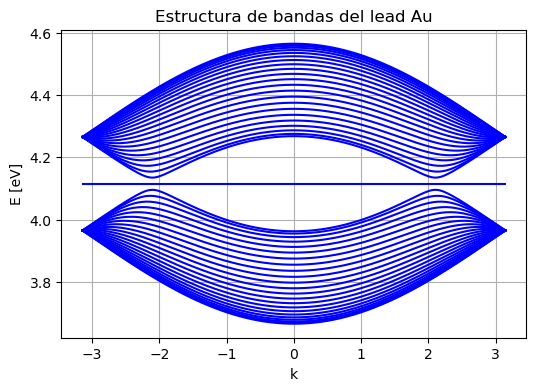

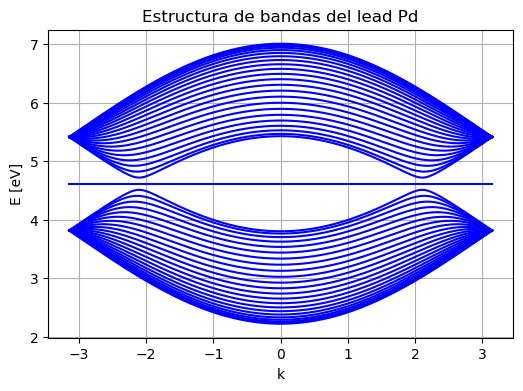

In [21]:
## Construcción del sistema
# Para Au
syst_Au, lead_left_Au, lead_right_Au = construir_sistema('Au')
plot_bandas(lead_left_Au, 'Au')

# Para Pd
syst_Pd, lead_left_Pd, lead_right_Pd = construir_sistema('Pd')
plot_bandas(lead_left_Pd, 'Pd')

Visualizando el rGO "completo"

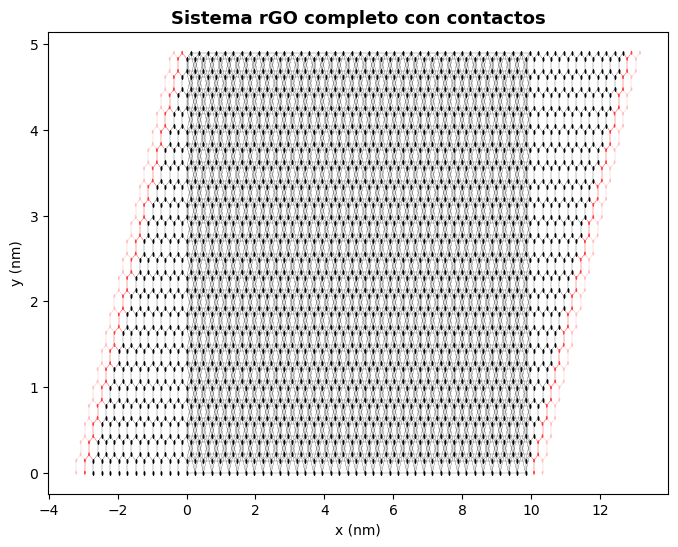

In [22]:
# Bloque 1: Sistema completo con leads
fig, ax = plt.subplots(figsize=(8,6))
kwant.plot(syst, ax=ax, site_size=0.2, site_color='k', hop_lw=0.05,
           lead_site_size=0.15, lead_color='r')
ax.set_title('Sistema rGO completo con contactos', fontsize=13, fontweight='bold')
ax.set_xlabel('x (nm)'); ax.set_ylabel('y (nm)')
plt.show()

Red Hexagonal
Visualizar una subred hexagonal simplificada

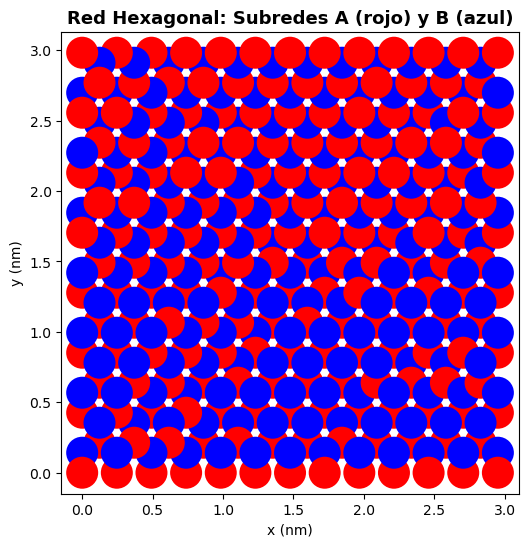

In [24]:
# Construcción de la red pequeña
# Construcción de la red pequeña
syst_small = kwant.Builder()

def shape_small(pos):
    x, y = pos
    return 0 <= x <= 3 and 0 <= y <= 3

syst_small[lat.shape(shape_small, (1.5, 1.5))] = epsilon_0
syst_small[lat.neighbors()] = -t1

# Usar una función para asignar el color en lugar de una lista
def color_subred(site):
    return 'r' if site.family == a else 'b'

fig, ax = plt.subplots(figsize=(6,6))
kwant.plot(syst_small, ax=ax, site_size=0.8, site_color=color_subred, hop_lw=0.5)
ax.set_title('Red Hexagonal: Subredes A (rojo) y B (azul)', fontsize=13, fontweight='bold')
ax.set_xlabel('x (nm)'); ax.set_ylabel('y (nm)')
ax.set_aspect('equal')
plt.show()

In [25]:
# Definir el rango de energías a evaluar (alrededor de epsilon_0)
energias = np.linspace(2.5, 4.5, 50)

print("--- Calculando sistema con Oro (Au) ---")
syst_Au_fin = syst_Au.finalized()
results_Au = {
    'bandas': calcular_estructura_bandas(lead_left_Au.finalized()),
    'transmision': calcular_transmision(syst_Au_fin, energias),
    'dos': calcular_DOS(syst_Au_fin, energias)
}

print("--- Calculando sistema con Paladio (Pd) ---")
syst_Pd_fin = syst_Pd.finalized()
results_Pd = {
    'bandas': calcular_estructura_bandas(lead_left_Pd.finalized()),
    'transmision': calcular_transmision(syst_Pd_fin, energias),
    'dos': calcular_DOS(syst_Pd_fin, energias)
}

--- Calculando sistema con Oro (Au) ---
Calculando transmisión...
  Progreso: 10/50 energías
  Progreso: 20/50 energías
  Progreso: 30/50 energías
  Progreso: 40/50 energías
  Progreso: 50/50 energías
✓ Transmisión calculada

Calculando DOS...
  Progreso: 10/50 energías
  Progreso: 20/50 energías
  Progreso: 30/50 energías
  Progreso: 40/50 energías
  Progreso: 50/50 energías
✓ DOS calculada

--- Calculando sistema con Paladio (Pd) ---
Calculando transmisión...
  Progreso: 10/50 energías
  Progreso: 20/50 energías
  Progreso: 30/50 energías
  Progreso: 40/50 energías
  Progreso: 50/50 energías
✓ Transmisión calculada

Calculando DOS...
  Progreso: 10/50 energías
  Progreso: 20/50 energías
  Progreso: 30/50 energías
  Progreso: 40/50 energías
  Progreso: 50/50 energías
✓ DOS calculada



Banda de energias de los Leads

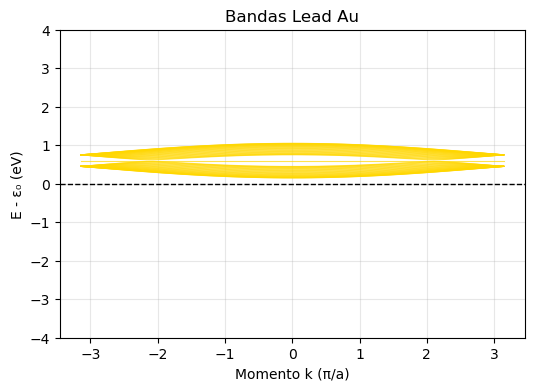

In [26]:
fig, ax = plt.subplots(figsize=(6,4))
k, bands_Au = results_Au['bandas']
ax.plot(k, bands_Au - epsilon_0, 'gold', linewidth=0.8, alpha=0.7)
ax.axhline(0, color='k', linestyle='--', linewidth=1)
ax.set_xlabel('Momento k (π/a)'); ax.set_ylabel('E - ε₀ (eV)')
ax.set_title('Bandas Lead Au'); ax.grid(True, alpha=0.3); ax.set_ylim([-4,4])
plt.show()

Transmisión comparativa Au vs Pd

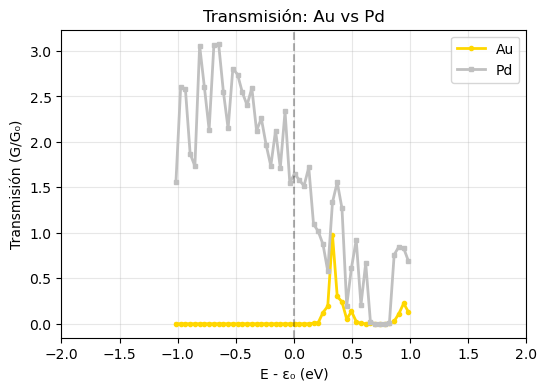

In [27]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(energias - epsilon_0, results_Au['transmision'], 'o-', label='Au', color='gold', linewidth=2, markersize=3)
ax.plot(energias - epsilon_0, results_Pd['transmision'], 's-', label='Pd', color='silver', linewidth=2, markersize=3)
ax.axvline(0, color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('E - ε₀ (eV)'); ax.set_ylabel('Transmisión (G/G₀)')
ax.set_title('Transmisión: Au vs Pd'); ax.legend(); ax.grid(True, alpha=0.3); ax.set_xlim([-2,2])
plt.show()

DOS de Au y Pd

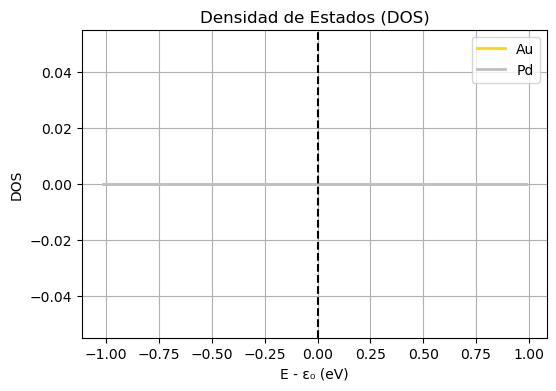

In [29]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(energias - epsilon_0, results_Au['dos'], color='gold', linewidth=2, label='Au')
ax.plot(energias - epsilon_0, results_Pd['dos'], color='silver', linewidth=2, label='Pd')
ax.axvline(0, color='k', linestyle='--')
ax.set_xlabel('E - ε₀ (eV)'); ax.set_ylabel('DOS'); ax.set_title('Densidad de Estados (DOS)')
ax.legend(); ax.grid(True)
plt.show()

Resistencia del contacto

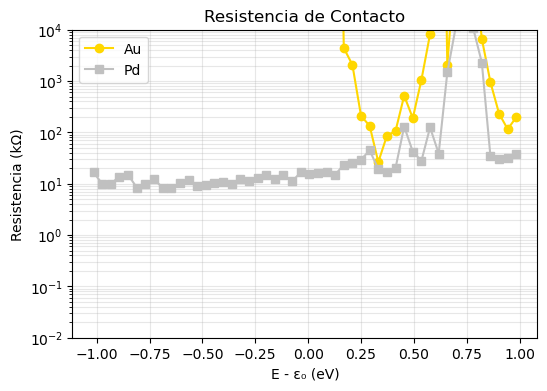

In [30]:
def calcular_resistencia(T):
    """Convierte transmisión en resistencia (kΩ)."""
    G0 = 1  # Normalizado
    R = 1/(T + 1e-12) * 25.813  # kΩ
    return R

R_Au = calcular_resistencia(results_Au['transmision'])
R_Pd = calcular_resistencia(results_Pd['transmision'])

fig, ax = plt.subplots(figsize=(6,4))
ax.semilogy(energias - epsilon_0, R_Au, 'o-', color='gold', label='Au')
ax.semilogy(energias - epsilon_0, R_Pd, 's-', color='silver', label='Pd')
ax.set_xlabel('E - ε₀ (eV)'); ax.set_ylabel('Resistencia (kΩ)')
ax.set_title('Resistencia de Contacto'); ax.legend(); ax.grid(True, alpha=0.3, which='both')
ax.set_ylim([1e-2, 1e4])
plt.show()

Creando algunas nanocintas

In [31]:
def make_graphene_nanoribbon(L, W, edge_type='zigzag'):
    """
    Crea una nanocinta de grafeno con bordes específicos
    
    edge_type: 'zigzag' o 'armchair'
    """
    lat = kwant.lattice.honeycomb(a=a_graphene, norbs=1)
    a, b = lat.sublattices
    
    syst = kwant.Builder()
    
    if edge_type == 'zigzag':
        # Nanocinta zigzag
        def shape_zigzag(pos):
            x, y = pos
            return 0 <= y <= W and 0 <= x <= L
        
        syst[lat.shape(shape_zigzag, (L/2, W/2))] = epsilon_0
    else:  # armchair
        # Nanocinta armchair (rotada)
        def shape_armchair(pos):
            x, y = pos
            return 0 <= x <= L and 0 <= y <= W
        
        syst[lat.shape(shape_armchair, (L/2, W/2))] = epsilon_0
    
    # Hoppings
    syst[lat.neighbors()] = -t1
    syst[a.neighbors()] = -t2
    syst[b.neighbors()] = -t2
    
    # Leads
    sym = kwant.TranslationalSymmetry(lat.vec((1, 0)))
    lead = kwant.Builder(sym)
    
    def shape_lead(pos):
        x, y = pos
        return 0 <= y <= W
    
    lead[lat.shape(shape_lead, (0, W/2))] = epsilon_0
    lead[lat.neighbors()] = -t1
    
    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    
    return syst

In [32]:
def analyze_edge_states(syst, energies):
    """
    Analiza estados de borde calculando LDOS cerca de los bordes
    """
    print("Analizando estados de borde...")
    
    syst_final = syst.finalized()
    
    # Identificar sitios en el borde y en el centro
    sites = list(syst_final.sites())
    positions = np.array([site.pos for site in sites])
    
    y_min, y_max = positions[:, 1].min(), positions[:, 1].max()
    
    edge_bottom = [i for i, pos in enumerate(positions) 
                   if pos[1] < y_min + 0.5]
    edge_top = [i for i, pos in enumerate(positions) 
                if pos[1] > y_max - 0.5]
    center = [i for i, pos in enumerate(positions) 
              if abs(pos[1] - (y_max + y_min)/2) < 1.0]
    
    # Calcular LDOS
    ldos_edge = []
    ldos_center = []
    
    for E in energies:
        try:
            # Función de Green
            G = kwant.greens_function(syst_final, energy=E)
            
            # LDOS en el borde (promedio)
            ldos_e = np.mean([abs(G.greens_function(i, i).real) 
                             for i in edge_bottom[:5]])
            # LDOS en el centro
            ldos_c = np.mean([abs(G.greens_function(i, i).real) 
                             for i in center[:5]])
            
            ldos_edge.append(ldos_e)
            ldos_center.append(ldos_c)
        except:
            ldos_edge.append(0)
            ldos_center.append(0)
    
    return np.array(ldos_edge), np.array(ldos_center)

In [33]:
def calculate_participation_ratio(wavefunction):
    """
    Calcula el Participation Ratio (PR)
    PR = [Σ|ψᵢ|²]² / Σ|ψᵢ|⁴
    
    PR ~ 1: estado localizado
    PR ~ N: estado extendido
    """
    psi_squared = np.abs(wavefunction)**2
    numerator = np.sum(psi_squared)**2
    denominator = np.sum(psi_squared**2)
    
    if denominator > 1e-10:
        return numerator / denominator
    else:
        return 0


In [34]:
def analyze_localization(syst, energies, disorder_strengths):
    """
    Analiza la localización en función del desorden
    """
    print("Analizando localización de Anderson...")
    
    results = {}
    
    for W in disorder_strengths:
        print(f"  Desorden W = {W:.3f} eV")
        
        # Crear sistema con desorden
        lat = kwant.lattice.honeycomb(a=a_graphene, norbs=1)
        L, W_sys = 20, 10
        
        syst_dis = kwant.Builder()
        
        def shape(pos):
            x, y = pos
            return 0 <= x <= L and 0 <= y <= W_sys
        
        # On-site con desorden
        rng = np.random.RandomState(42)
        
        for site in lat.shape(shape, (L/2, W_sys/2)):
            disorder = W * (rng.random() - 0.5)
            syst_dis[site] = epsilon_0 + disorder
        
        syst_dis[lat.neighbors()] = -t1
        
        # Leads sin desorden
        sym = kwant.TranslationalSymmetry(lat.vec((1, 0)))
        lead = kwant.Builder(sym)
        
        def shape_lead(pos):
            x, y = pos
            return 0 <= y <= W_sys
        
        lead[lat.shape(shape_lead, (0, W_sys/2))] = epsilon_0
        lead[lat.neighbors()] = -t1
        
        syst_dis.attach_lead(lead)
        syst_dis.attach_lead(lead.reversed())
        
        syst_final = syst_dis.finalized()
        
        # Calcular PR para diferentes energías
        pr_values = []
        
        for E in energies:
            try:
                wf = kwant.wave_function(syst_final, energy=E)
                psi = wf(0)[0]  # Primera función de onda del lead 0
                pr = calculate_participation_ratio(psi)
                pr_values.append(pr)
            except:
                pr_values.append(0)
        
        results[W] = np.array(pr_values)
    
    return results

In [35]:
def analyze_oxygen_dependence(L, W, oxygen_concentrations):
    """
    Analiza cómo la concentración de oxígeno afecta las propiedades
    """
    print("Analizando dependencia con oxígeno...")
    
    lat = kwant.lattice.honeycomb(a=a_graphene, norbs=1)
    energies = epsilon_0 + np.linspace(-1, 1, 21)
    
    results = {
        'transmision': {},
        'dos': {},
        'gap': []
    }
    
    for conc in oxygen_concentrations:
        print(f"  Concentración O: {conc*100:.1f}%")
        
        # Crear sistema
        syst = kwant.Builder()
        
        def shape(pos):
            x, y = pos
            return 0 <= x <= L and 0 <= y <= W
        
        # Llenar sin desorden inicialmente
        syst[lat.shape(shape, (L/2, W/2))] = epsilon_0
        syst[lat.neighbors()] = -t1
        syst[lat.sublattices[0].neighbors()] = -t2
        syst[lat.sublattices[1].neighbors()] = -t2
        
        # Agregar oxígeno
        rng = np.random.RandomState(123)
        sites_list = list(syst.sites())
        n_oxygen = int(len(sites_list) * conc)
        oxygen_sites = rng.choice(sites_list, n_oxygen, replace=False)
        
        epsilon_O = 0.8  # eV
        for site in oxygen_sites:
            syst[site] = epsilon_0 + epsilon_O
        
        # Leads
        sym = kwant.TranslationalSymmetry(lat.vec((1, 0)))
        lead = kwant.Builder(sym)
        
        def shape_lead(pos):
            x, y = pos
            return 0 <= y <= W
        
        lead[lat.shape(shape_lead, (0, W/2))] = epsilon_0
        lead[lat.neighbors()] = -t1
        
        syst.attach_lead(lead)
        syst.attach_lead(lead.reversed())
        
        syst_final = syst.finalized()
        
        # Calcular transmisión
        trans = []
        dos_vals = []
        
        for E in energies:
            try:
                smatrix = kwant.smatrix(syst_final, energy=E)
                T = smatrix.transmission(1, 0)
                trans.append(T)
                
                # DOS
                G = kwant.greens_function(syst_final, energy=E)
                dos_vals.append(G.density())
            except:
                trans.append(0)
                dos_vals.append(0)
        
        results['transmision'][conc] = np.array(trans)
        results['dos'][conc] = np.array(dos_vals)
        
        # Estimar gap (región de baja transmisión)
        T_threshold = 0.1 * np.max(trans)
        gap_region = energies[trans < T_threshold]
        if len(gap_region) > 0:
            gap_width = gap_region.max() - gap_region.min()
            results['gap'].append(gap_width)
        else:
            results['gap'].append(0)
    
    return results, energies

In [36]:
def plot_disorder_map(syst, lat):
    """
    Mapea espacialmente el desorden en el sistema
    """
    print("Generando mapa de desorden...")
    
    # Extraer energías on-site
    sites = list(syst.sites())
    positions = np.array([site.pos for site in sites])
    energies_onsite = np.array([syst[site] for site in sites])
    
    # Desviación respecto a ε₀
    disorder_values = energies_onsite - epsilon_0
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Scatter plot con mapa de color
    scatter = ax.scatter(positions[:, 0], positions[:, 1], 
                        c=disorder_values, cmap='RdBu_r', 
                        s=50, edgecolors='k', linewidths=0.5,
                        vmin=-1, vmax=1)
    
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Desorden (E - ε₀) [eV]', fontsize=11)
    
    ax.set_xlabel('x (nm)', fontsize=11)
    ax.set_ylabel('y (nm)', fontsize=11)
    ax.set_title('Mapa Espacial del Desorden en rGO', 
                fontsize=13, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    return fig

In [37]:
def plot_comprehensive_analysis():
    """
    Ejecuta y visualiza todos los análisis
    """
    print("\n" + "="*70)
    print(" ANÁLISIS COMPLEMENTARIO DE rGO")
    print("="*70 + "\n")
    
    # Configuración
    L, W = 30, 10
    energies = epsilon_0 + np.linspace(-2, 2, 41)
    
    fig = plt.figure(figsize=(18, 14))
    gs = GridSpec(4, 3, figure=fig, hspace=0.35, wspace=0.3)
    
    # 1. ESTADOS DE BORDE - ZIGZAG
    print("1. Analizando nanocintas zigzag...")
    syst_zigzag = make_graphene_nanoribbon(L, W, edge_type='zigzag')
    ldos_edge_zz, ldos_center_zz = analyze_edge_states(syst_zigzag, energies)
    
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(energies - epsilon_0, ldos_edge_zz, 'r-', linewidth=2, 
            label='Borde')
    ax1.plot(energies - epsilon_0, ldos_center_zz, 'b-', linewidth=2, 
            label='Centro')
    ax1.axvline(0, color='k', linestyle='--', alpha=0.3)
    ax1.set_xlabel('E - ε₀ (eV)', fontsize=10)
    ax1.set_ylabel('LDOS', fontsize=10)
    ax1.set_title('Estados de Borde (Zigzag)', fontsize=11, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # 2. STRUCTURE - ZIGZAG
    ax2 = fig.add_subplot(gs[0, 1])
    kwant.plot(syst_zigzag, ax=ax2, site_size=0.15, site_color=['r', 'b'],
              hop_lw=0.05)
    ax2.set_title('Nanocinta Zigzag', fontsize=11, fontweight='bold')
    
    # 3. BANDAS - ZIGZAG
    ax3 = fig.add_subplot(gs[0, 2])
    syst_zz_final = syst_zigzag.finalized()
    kwant.plotter.bands(syst_zz_final.leads[0], ax=ax3)
    ax3.axhline(epsilon_0, color='k', linestyle='--', alpha=0.3)
    ax3.set_ylabel('Energía (eV)', fontsize=10)
    ax3.set_xlabel('k', fontsize=10)
    ax3.set_title('Bandas del Lead', fontsize=11, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # 4. LOCALIZACIÓN DE ANDERSON
    print("\n2. Analizando localización de Anderson...")
    disorder_strengths = [0.0, 0.5, 1.0, 1.5]
    energies_loc = epsilon_0 + np.linspace(-1, 1, 21)
    loc_results = analyze_localization(syst_zigzag, energies_loc, 
                                       disorder_strengths)
    
    ax4 = fig.add_subplot(gs[1, :])
    colors = plt.cm.viridis(np.linspace(0, 1, len(disorder_strengths)))
    
    for i, W_dis in enumerate(disorder_strengths):
        pr = loc_results[W_dis]
        ax4.plot(energies_loc - epsilon_0, pr, 'o-', 
                color=colors[i], linewidth=2, markersize=4,
                label=f'W = {W_dis:.1f} eV')
    
    ax4.axvline(0, color='k', linestyle='--', alpha=0.3)
    ax4.set_xlabel('E - ε₀ (eV)', fontsize=11)
    ax4.set_ylabel('Participation Ratio', fontsize=11)
    ax4.set_title('Localización de Anderson', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=10, ncol=4)
    ax4.grid(True, alpha=0.3)
    ax4.set_yscale('log')
    
    # 5. DEPENDENCIA CON OXÍGENO - TRANSMISIÓN
    print("\n3. Analizando dependencia con oxígeno...")
    oxygen_concs = [0.0, 0.05, 0.10, 0.15, 0.20]
    oxygen_results, energies_O = analyze_oxygen_dependence(L, W, oxygen_concs)
    
    ax5 = fig.add_subplot(gs[2, 0])
    colors_O = plt.cm.Reds(np.linspace(0.3, 1, len(oxygen_concs)))
    
    for i, conc in enumerate(oxygen_concs):
        trans = oxygen_results['transmision'][conc]
        ax5.plot(energies_O - epsilon_0, trans, 'o-', 
                color=colors_O[i], linewidth=1.5, markersize=3,
                label=f'{conc*100:.0f}% O')
    
    ax5.axvline(0, color='k', linestyle='--', alpha=0.3)
    ax5.set_xlabel('E - ε₀ (eV)', fontsize=10)
    ax5.set_ylabel('Transmisión', fontsize=10)
    ax5.set_title('Efecto del Oxígeno en Transmisión', 
                 fontsize=11, fontweight='bold')
    ax5.legend(fontsize=8)
    ax5.grid(True, alpha=0.3)
    
    # 6. DEPENDENCIA CON OXÍGENO - DOS
    ax6 = fig.add_subplot(gs[2, 1])
    
    for i, conc in enumerate(oxygen_concs):
        dos = oxygen_results['dos'][conc]
        ax6.plot(energies_O - epsilon_0, dos, '-', 
                color=colors_O[i], linewidth=1.5,
                label=f'{conc*100:.0f}% O')
    
    ax6.axvline(0, color='k', linestyle='--', alpha=0.3)
    ax6.set_xlabel('E - ε₀ (eV)', fontsize=10)
    ax6.set_ylabel('DOS', fontsize=10)
    ax6.set_title('Efecto del Oxígeno en DOS', fontsize=11, fontweight='bold')
    ax6.legend(fontsize=8)
    ax6.grid(True, alpha=0.3)
    
    # 7. GAP vs CONCENTRACIÓN DE OXÍGENO
    ax7 = fig.add_subplot(gs[2, 2])
    gaps = oxygen_results['gap']
    ax7.plot(np.array(oxygen_concs)*100, gaps, 'ro-', 
            linewidth=2, markersize=8)
    ax7.set_xlabel('Concentración de O (%)', fontsize=10)
    ax7.set_ylabel('Gap efectivo (eV)', fontsize=10)
    ax7.set_title('Gap vs Concentración de Oxígeno', 
                 fontsize=11, fontweight='bold')
    ax7.grid(True, alpha=0.3)
    
    # 8. MAPA DE DESORDEN
    print("\n4. Generando mapa de desorden...")
    lat = kwant.lattice.honeycomb(a=a_graphene, norbs=1)
    syst_disorder = kwant.Builder()
    
    def shape(pos):
        x, y = pos
        return 0 <= x <= 15 and 0 <= y <= 8
    
    # Crear sistema con desorden mixto
    rng = np.random.RandomState(42)
    for site in lat.shape(shape, (7.5, 4)):
        disorder = 0.5 * (rng.random() - 0.5)  # Anderson
        if rng.random() < 0.15:  # Oxígeno
            disorder += 0.8
        syst_disorder[site] = epsilon_0 + disorder
    
    syst_disorder[lat.neighbors()] = -t1
    
    ax8 = fig.add_subplot(gs[3, :2])
    positions = np.array([site.pos for site in syst_disorder.sites()])
    disorder_vals = np.array([syst_disorder[site] - epsilon_0 
                             for site in syst_disorder.sites()])
    
    scatter = ax8.scatter(positions[:, 0], positions[:, 1],
                         c=disorder_vals, cmap='RdBu_r',
                         s=80, edgecolors='k', linewidths=0.5,
                         vmin=-1, vmax=1.5)
    
    cbar = plt.colorbar(scatter, ax=ax8)
    cbar.set_label('E - ε₀ (eV)', fontsize=10)
    ax8.set_xlabel('x (nm)', fontsize=10)
    ax8.set_ylabel('y (nm)', fontsize=10)
    ax8.set_title('Mapa Espacial: Anderson + Oxígeno', 
                 fontsize=11, fontweight='bold')
    ax8.set_aspect('equal')
    ax8.grid(True, alpha=0.3)
    
    # 9. TABLA RESUMEN
    ax9 = fig.add_subplot(gs[3, 2])
    ax9.axis('off')
    
    table_data = [
        ['Efecto', 'Valor', 'Impacto'],
        ['Desorden', 'W=0.5 eV', 'Localización'],
        ['Oxígeno', '10-20%', '↑ Gap'],
        ['Borde zigzag', '—', 'Estados 0D'],
        ['t₁', f'{t1:.3f} eV', 'Primeros vec.'],
        ['t₂', f'{t2:.3f} eV', 'Segundos vec.'],
        ['ε₀', f'{epsilon_0:.3f} eV', 'On-site'],
    ]
    
    table = ax9.table(cellText=table_data, cellLoc='center',
                     loc='center', colWidths=[0.3, 0.35, 0.35])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    
    for i in range(len(table_data)):
        for j in range(3):
            cell = table[(i, j)]
            if i == 0:
                cell.set_facecolor('#1976D2')
                cell.set_text_props(weight='bold', color='white')
            else:
                if j == 0:
                    cell.set_facecolor('#E3F2FD')
                else:
                    cell.set_facecolor('#F5F5F5')
    
    ax9.set_title('Resumen de Parámetros', fontsize=11, 
                 fontweight='bold', pad=10)
    
    plt.suptitle('Análisis Complementario: Estados de Borde, Localización y Efectos del Oxígeno',
                fontsize=14, fontweight='bold', y=0.995)
    
    print("\n" + "="*70)
    print(" ANÁLISIS COMPLETADO")
    print("="*70 + "\n")
    
    return fig

In [39]:
fig = plot_comprehensive_analysis()
plt.show()



 ANÁLISIS COMPLEMENTARIO DE rGO

1. Analizando nanocintas zigzag...
Analizando estados de borde...


TypeError: 'tuple' object is not callable

<Figure size 1800x1400 with 0 Axes>